# 📊 Análise Exploratória de Dados — Previsão de Alagamentos em SP
## TCC · Henrique Nascimento Santos

**Fontes de dados:**
- `final_data.csv` — Registros de alagamentos do CGE (2015–2026)
- `open_meteo_sp.csv` — Variáveis meteorológicas e de solo via ERA5/Open-Meteo
- `consolidated_dataset.csv` — Dataset consolidado com variáveis INMET (IDW)

**Objetivo desta análise:** entender a distribuição, correlações e padrões sazonais das variáveis antes da modelagem.


In [1]:
# ── Configuração ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Estilo visual
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE  = ["#378ADD", "#E05252"]
BLUE     = "#378ADD"
RED      = "#E05252"
GREEN    = "#1D9E75"
ORANGE   = "#EF9F27"

print("✓ Bibliotecas carregadas.")


✓ Bibliotecas carregadas.


## 1. Carregamento e Merge dos Dados

In [2]:
# Ajuste os caminhos conforme sua estrutura de projeto
PATH_ALAG  = "../../data/outputs/datasets/final_data.csv"
PATH_METEO = "../../data/outputs/datasets/open_meteo_sp.csv"
PATH_CONS  = "../../data/outputs/datasets/consolidated_dataset.csv"  # opcional

# ── Alagamentos ───────────────────────────────────────────────────────────
alag_raw = pd.read_csv(PATH_ALAG)
alag_raw["date"] = pd.to_datetime(alag_raw["date"], format="%d-%m-%Y", errors="coerce")

# Target diário
alag_daily = (
    alag_raw.groupby("date")
    .agg(
        n_events       = ("current_zone", "count"),
        n_intransit    = ("status", lambda x: (x == "Inativo Intransitável").sum()),
        zones_affected = ("current_zone", lambda x: x.dropna().nunique()),
        has_flooding   = ("current_zone", lambda x: int(x.notna().any())),
    )
    .reset_index()
)
all_days  = pd.DataFrame({"date": pd.date_range("2015-01-01", "2026-05-31")})
alag_daily = pd.merge(all_days, alag_daily, on="date", how="left")
alag_daily["has_flooding"] = alag_daily["has_flooding"].fillna(0).astype(int)
alag_daily[["n_events","n_intransit","zones_affected"]] = alag_daily[["n_events","n_intransit","zones_affected"]].fillna(0)

# ── Open-Meteo ────────────────────────────────────────────────────────────
meteo = pd.read_csv(PATH_METEO)
meteo["date"] = pd.to_datetime(meteo["date"])

# ── Dataset final ─────────────────────────────────────────────────────────
df = pd.merge(alag_daily, meteo, on="date", how="left")
df["month"]     = df["date"].dt.month
df["year"]      = df["date"].dt.year
df["dayofweek"] = df["date"].dt.dayofweek
df["is_summer"] = df["month"].isin([11,12,1,2,3]).astype(int)

MONTH_NAMES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
ZONE_LABELS = alag_raw["current_zone"].dropna().unique().tolist()

print(f"✓ Dataset final: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Dias com alagamento : {df['has_flooding'].sum():,} ({df['has_flooding'].mean()*100:.1f}%)")
print(f"  Dias sem alagamento : {(df['has_flooding']==0).sum():,} ({(1-df['has_flooding'].mean())*100:.1f}%)")


✓ Dataset final: 4,169 linhas × 32 colunas
  Período: 2015-01-01 → 2026-05-31
  Dias com alagamento : 1,031 (24.7%)
  Dias sem alagamento : 3,138 (75.3%)


## 2. Qualidade dos Dados

In [3]:
# Nulos e dtypes
print("=== Tipos de dados e valores nulos ===")
info = pd.DataFrame({
    "dtype"   : df.dtypes.astype(str),
    "nulos"   : df.isnull().sum(),
    "nulos_%"  : (df.isnull().sum() / len(df) * 100).round(2),
    "únicos"  : df.nunique(),
})
info = info[info["nulos"] > 0].sort_values("nulos_%", ascending=False)
print(info.to_string())


=== Tipos de dados e valores nulos ===
                            dtype  nulos  nulos_%  únicos
precipitation_sum_acc14d  float64     13     0.31    2232
precipitation_sum_acc7d   float64      6     0.14    2513
precipitation_sum_lag3d   float64      3     0.07     292
precipitation_sum_lag2d   float64      2     0.05     292
precipitation_sum_acc3d   float64      2     0.05    1532
precipitation_sum_lag1d   float64      1     0.02     292


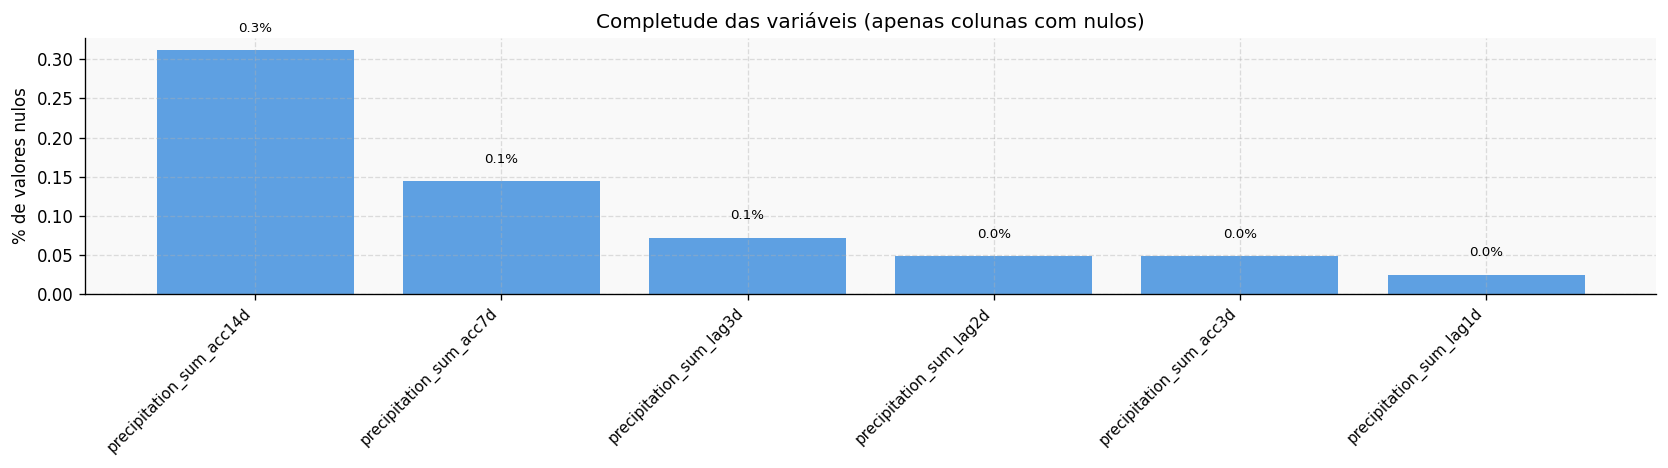

In [4]:
# Heatmap de nulos
fig, ax = plt.subplots(figsize=(14, 4))
null_pct = df.isnull().mean().sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

bars = ax.bar(range(len(null_pct)), null_pct.values * 100, color=BLUE, alpha=0.8)
ax.set_xticks(range(len(null_pct)))
ax.set_xticklabels(null_pct.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("% de valores nulos")
ax.set_title("Completude das variáveis (apenas colunas com nulos)")
for bar, v in zip(bars, null_pct.values * 100):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


## 3. Distribuição do Target (has_flooding)

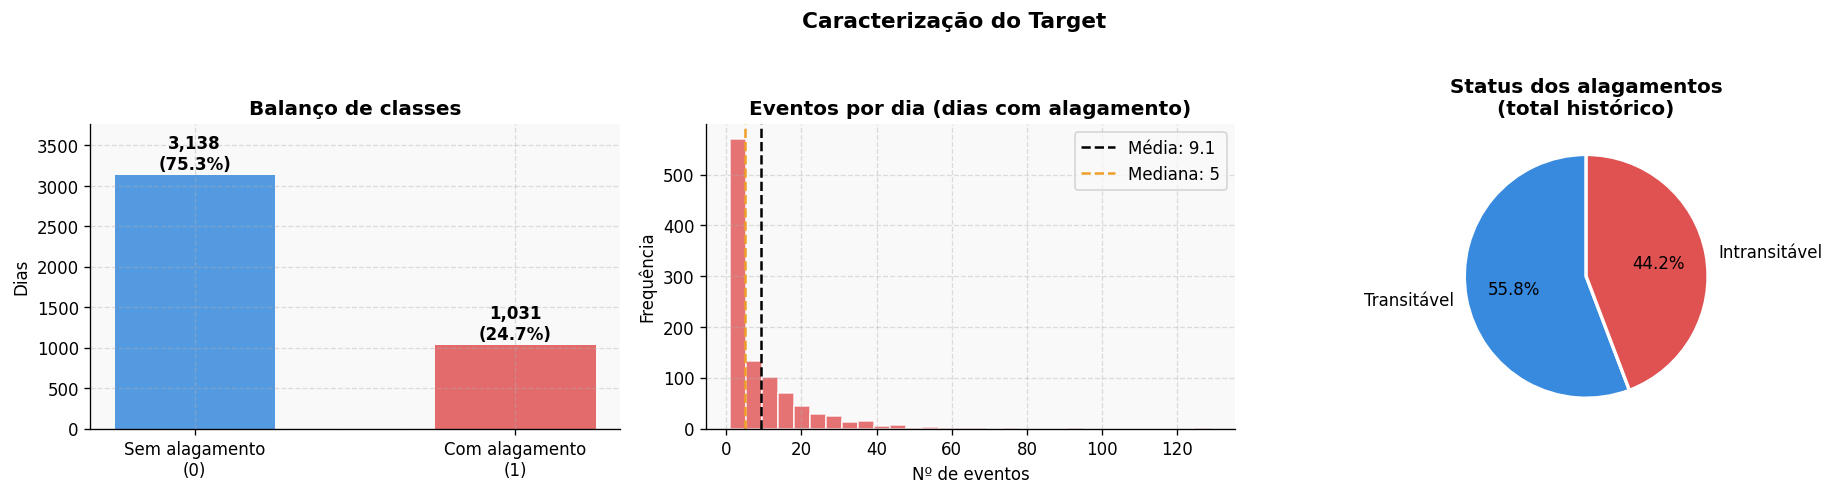


Índice de desbalanceamento (ratio negativo:positivo): 3.0:1
→ Será necessário usar class_weight='balanced' ou SMOTE na modelagem.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 3.1 Balanço de classes
ax = axes[0]
counts = df["has_flooding"].value_counts()
bars = ax.bar(["Sem alagamento\n(0)", "Com alagamento\n(1)"],
              counts.values, color=[BLUE, RED], alpha=0.85, width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 20, f"{v:,}\n({v/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Balanço de classes", fontweight="bold")
ax.set_ylabel("Dias")
ax.set_ylim(0, counts.max() * 1.2)

# 3.2 Número de eventos por dia (nos dias com alagamento)
ax = axes[1]
df_pos = df[df["has_flooding"] == 1]["n_events"]
ax.hist(df_pos, bins=30, color=RED, alpha=0.8, edgecolor="white")
ax.axvline(df_pos.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Média: {df_pos.mean():.1f}")
ax.axvline(df_pos.median(), color=ORANGE, linestyle="--", linewidth=1.5, label=f"Mediana: {df_pos.median():.0f}")
ax.set_title("Eventos por dia (dias com alagamento)", fontweight="bold")
ax.set_xlabel("Nº de eventos")
ax.set_ylabel("Frequência")
ax.legend()

# 3.3 Intransitáveis vs Transitáveis
ax = axes[2]
transitable   = df["n_events"].sum() - df["n_intransit"].sum()
intransitable = df["n_intransit"].sum()
ax.pie([transitable, intransitable],
       labels=["Transitável", "Intransitável"],
       colors=[BLUE, RED], autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor":"white", "linewidth":2})
ax.set_title("Status dos alagamentos\n(total histórico)", fontweight="bold")

plt.suptitle("Caracterização do Target", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nÍndice de desbalanceamento (ratio negativo:positivo): {(df['has_flooding']==0).sum()/(df['has_flooding']==1).sum():.1f}:1")
print("→ Será necessário usar class_weight='balanced' ou SMOTE na modelagem.")


## 4. Sazonalidade

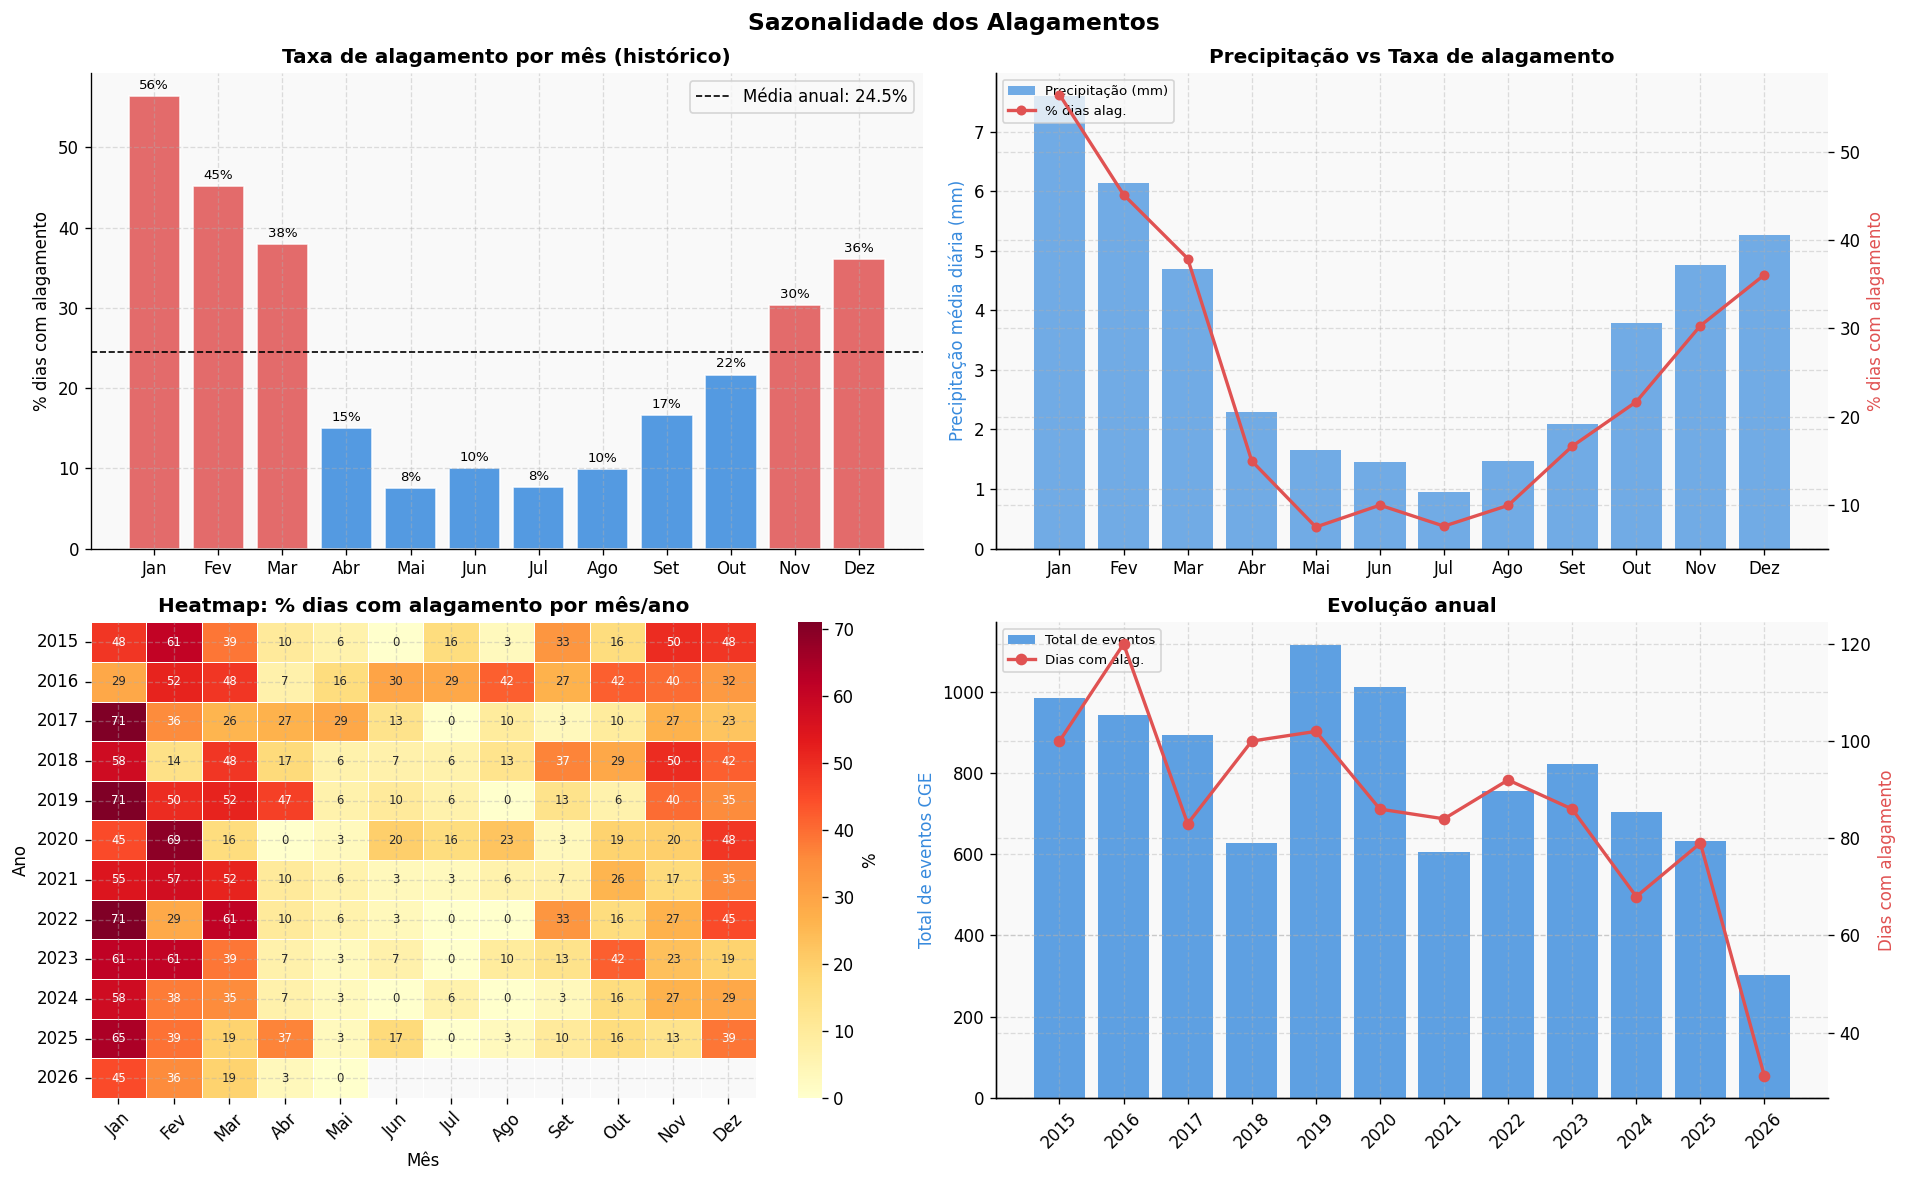

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

monthly_flood = df.groupby("month")["has_flooding"].agg(["mean","sum"]).reset_index()
monthly_precip = df.groupby("month")["precipitation_sum"].mean().reset_index()

# 4.1 Taxa de alagamento por mês
ax = axes[0, 0]
bars = ax.bar(range(1,13), monthly_flood["mean"]*100,
              color=[RED if v > monthly_flood["mean"].mean() else BLUE
                     for v in monthly_flood["mean"]],
              alpha=0.85, edgecolor="white")
ax.set_xticks(range(1,13))
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("% dias com alagamento")
ax.set_title("Taxa de alagamento por mês (histórico)", fontweight="bold")
ax.axhline(monthly_flood["mean"].mean()*100, color="black", linestyle="--",
           linewidth=1, label=f"Média anual: {monthly_flood['mean'].mean()*100:.1f}%")
ax.legend()
for bar, v in zip(bars, monthly_flood["mean"]*100):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.0f}%",
            ha="center", va="bottom", fontsize=8)

# 4.2 Precipitação média por mês
ax = axes[0, 1]
ax2 = ax.twinx()
ax.bar(range(1,13), monthly_precip["precipitation_sum"],
       color=BLUE, alpha=0.7, label="Precipitação (mm)")
ax2.plot(range(1,13), monthly_flood["mean"]*100,
         color=RED, marker="o", linewidth=2, markersize=5, label="% dias alag.")
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Precipitação média diária (mm)", color=BLUE)
ax2.set_ylabel("% dias com alagamento", color=RED)
ax.set_title("Precipitação vs Taxa de alagamento", fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc="upper left", fontsize=8)

# 4.3 Heatmap mês × ano
ax = axes[1, 0]
heatmap_data = df.groupby(["year","month"])["has_flooding"].mean().unstack() * 100
sns.heatmap(heatmap_data, ax=ax, cmap="YlOrRd", fmt=".0f", annot=True,
            linewidths=0.5, cbar_kws={"label":"%"}, annot_kws={"size":7})
ax.set_xlabel("Mês"); ax.set_ylabel("Ano")
ax.set_xticklabels(MONTH_NAMES, rotation=45)
ax.set_title("Heatmap: % dias com alagamento por mês/ano", fontweight="bold")

# 4.4 Eventos por ano
ax = axes[1, 1]
yearly = df.groupby("year").agg(
    n_events=("n_events","sum"),
    dias_alag=("has_flooding","sum")
).reset_index()
x = range(len(yearly))
bars = ax.bar(x, yearly["n_events"], color=BLUE, alpha=0.8, label="Total de eventos")
ax2 = ax.twinx()
ax2.plot(x, yearly["dias_alag"], color=RED, marker="o", linewidth=2, label="Dias com alag.")
ax.set_xticks(x); ax.set_xticklabels(yearly["year"], rotation=45)
ax.set_ylabel("Total de eventos CGE", color=BLUE)
ax2.set_ylabel("Dias com alagamento", color=RED)
ax.set_title("Evolução anual", fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc="upper left", fontsize=8)

plt.suptitle("Sazonalidade dos Alagamentos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Distribuição Geográfica (Zonas e Bairros)

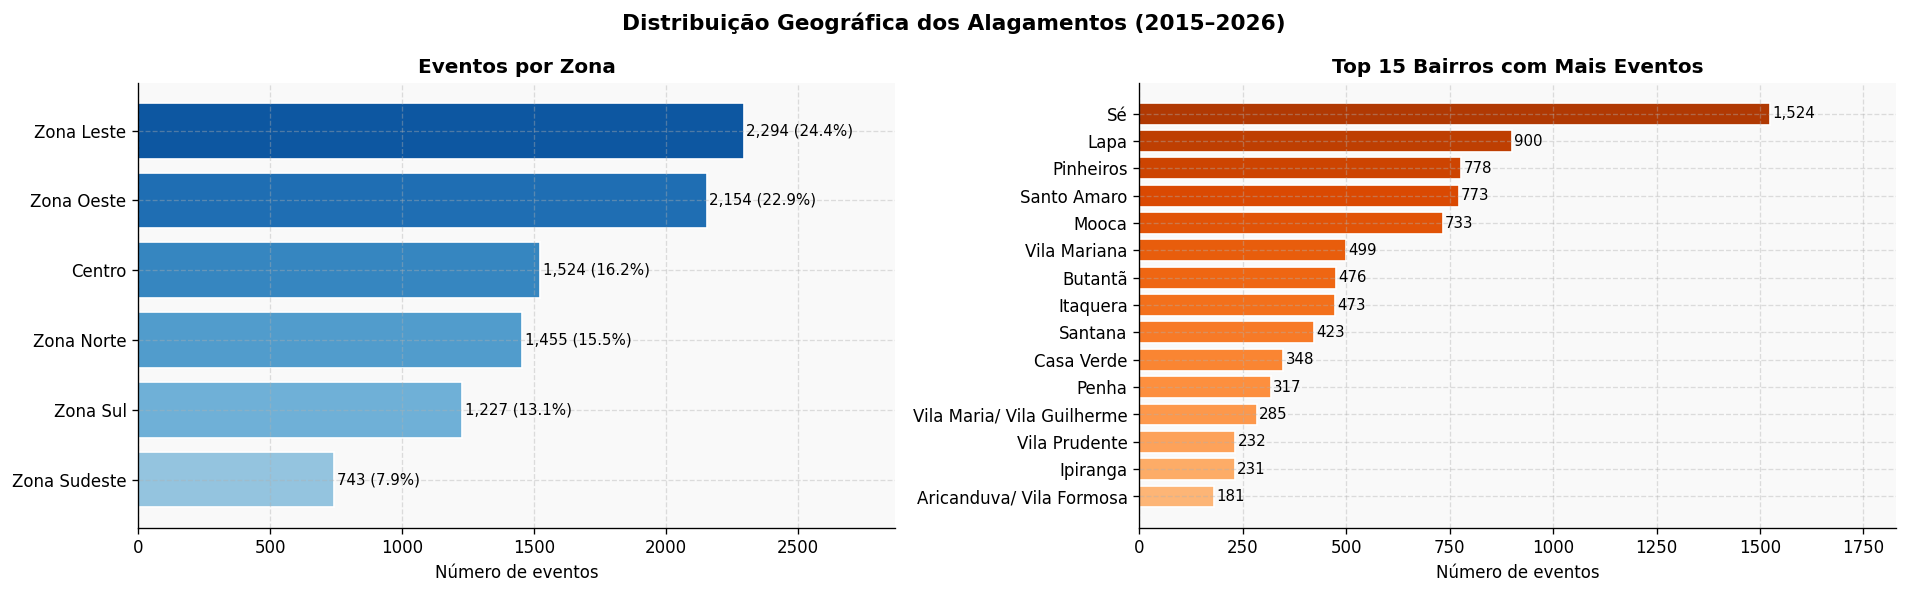

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 5.1 Por zona
zone_counts = alag_raw["current_zone"].value_counts()
colors_zone = plt.cm.Blues(np.linspace(0.4, 0.85, len(zone_counts)))[::-1]
axes[0].barh(zone_counts.index, zone_counts.values, color=colors_zone, edgecolor="white")
for i, (idx, v) in enumerate(zone_counts.items()):
    axes[0].text(v + 10, i, f"{v:,} ({v/zone_counts.sum()*100:.1f}%)",
                 va="center", fontsize=9)
axes[0].set_xlabel("Número de eventos")
axes[0].set_title("Eventos por Zona", fontweight="bold")
axes[0].set_xlim(0, zone_counts.max() * 1.25)
axes[0].invert_yaxis()

# 5.2 Top 15 bairros
neigh_counts = alag_raw["neighbor"].value_counts().head(15)
colors_neigh = plt.cm.Oranges(np.linspace(0.35, 0.85, len(neigh_counts)))[::-1]
axes[1].barh(neigh_counts.index, neigh_counts.values, color=colors_neigh, edgecolor="white")
for i, (idx, v) in enumerate(neigh_counts.items()):
    axes[1].text(v + 5, i, f"{v:,}", va="center", fontsize=9)
axes[1].set_xlabel("Número de eventos")
axes[1].set_title("Top 15 Bairros com Mais Eventos", fontweight="bold")
axes[1].set_xlim(0, neigh_counts.max() * 1.2)
axes[1].invert_yaxis()

plt.suptitle("Distribuição Geográfica dos Alagamentos (2015–2026)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Variáveis Meteorológicas — Open-Meteo (ERA5)

In [8]:
# Estatísticas descritivas por classe
METEO_COLS = [
    "precipitation_sum", "et0_fao_evapotranspiration",
    "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min",
    "relative_humidity_2m_mean", "wind_speed_10m_mean",
    "cloud_cover_mean", "shortwave_radiation_sum",
    "vapour_pressure_deficit_max",
    "soil_moisture_0_to_7cm_mean", "soil_moisture_7_to_28cm_mean",
]

desc = df.groupby("has_flooding")[METEO_COLS].mean().T
desc.columns = ["Sem alagamento (0)", "Com alagamento (1)"]
desc["Δ (%)"] = ((desc["Com alagamento (1)"] - desc["Sem alagamento (0)"]) / desc["Sem alagamento (0)"] * 100).round(1)
print("Médias por classe e diferença percentual:")
print(desc.to_string())


Médias por classe e diferença percentual:
                              Sem alagamento (0)  Com alagamento (1)  Δ (%)
precipitation_sum                       1.656628            9.274006  459.8
et0_fao_evapotranspiration              3.418250            3.352755   -1.9
temperature_2m_mean                    19.137859           21.015228    9.8
temperature_2m_max                     24.693340           25.698254    4.1
temperature_2m_min                     15.068419           17.800485   18.1
relative_humidity_2m_mean              78.830147           84.209505    6.8
wind_speed_10m_mean                    10.415966           10.036857   -3.6
cloud_cover_mean                       61.411727           80.304559   30.8
shortwave_radiation_sum                17.495644           16.994918   -2.9
vapour_pressure_deficit_max             1.578678            1.308797  -17.1
soil_moisture_0_to_7cm_mean             0.338832            0.422407   24.7
soil_moisture_7_to_28cm_mean            0.4015

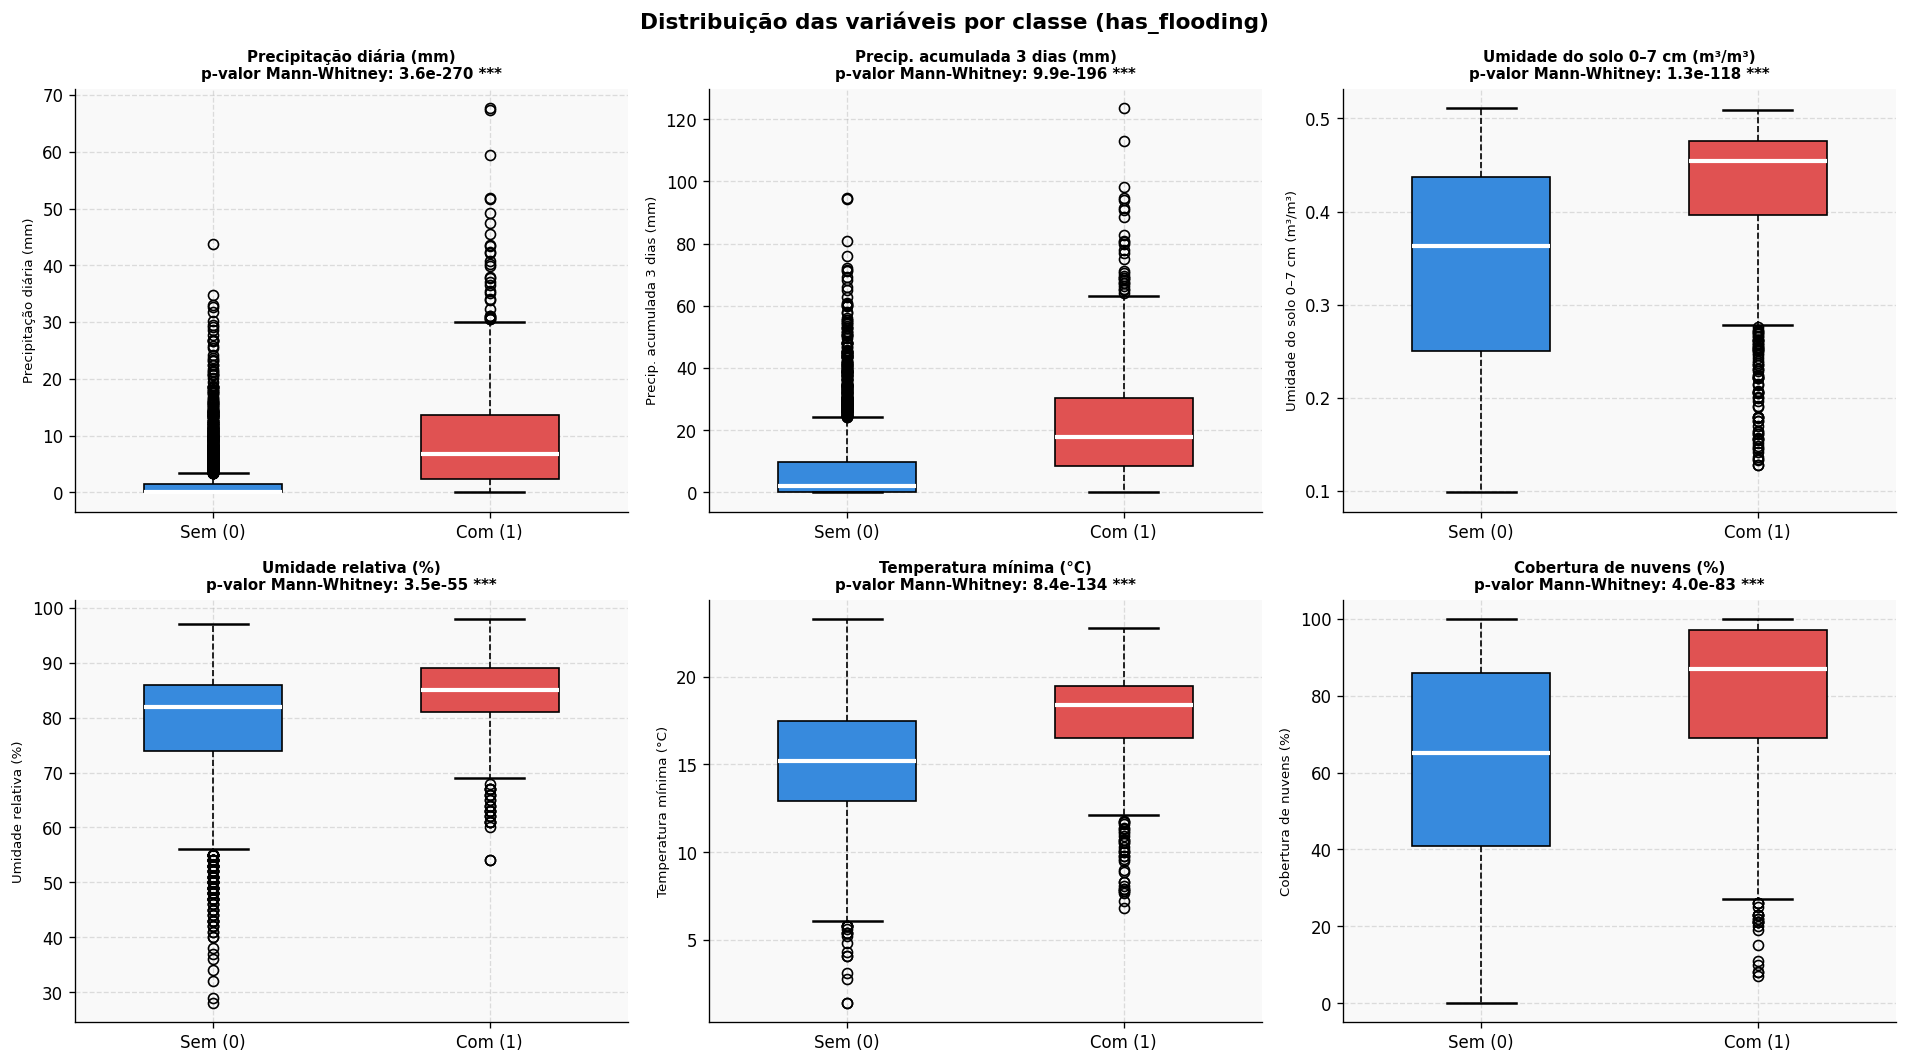

Legenda: *** p<0.001  ** p<0.01  * p<0.05  ns = não significativo


In [9]:
# Boxplots — variáveis chave por classe
KEY_VARS = [
    ("precipitation_sum",         "Precipitação diária (mm)"),
    ("precipitation_sum_acc3d",   "Precip. acumulada 3 dias (mm)"),
    ("soil_moisture_0_to_7cm_mean","Umidade do solo 0–7 cm (m³/m³)"),
    ("relative_humidity_2m_mean", "Umidade relativa (%)"),
    ("temperature_2m_min",        "Temperatura mínima (°C)"),
    ("cloud_cover_mean",          "Cobertura de nuvens (%)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, KEY_VARS):
    data = [df[df["has_flooding"]==0][col].dropna(),
            df[df["has_flooding"]==1][col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2.5))
    bp["boxes"][0].set_facecolor(BLUE)
    bp["boxes"][1].set_facecolor(RED)
    for cap in bp["caps"]: cap.set_linewidth(1.5)
    for whisker in bp["whiskers"]: whisker.set_linestyle("--")

    # Teste Mann-Whitney
    stat, p = stats.mannwhitneyu(data[0], data[1], alternative="two-sided")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.set_title(f"{label}\np-valor Mann-Whitney: {p:.1e} {sig}", fontsize=9, fontweight="bold")
    ax.set_xticklabels(["Sem (0)", "Com (1)"])
    ax.set_ylabel(label, fontsize=8)

plt.suptitle("Distribuição das variáveis por classe (has_flooding)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Legenda: *** p<0.001  ** p<0.01  * p<0.05  ns = não significativo")


## 7. Umidade do Solo e Efeito de Solo Saturado

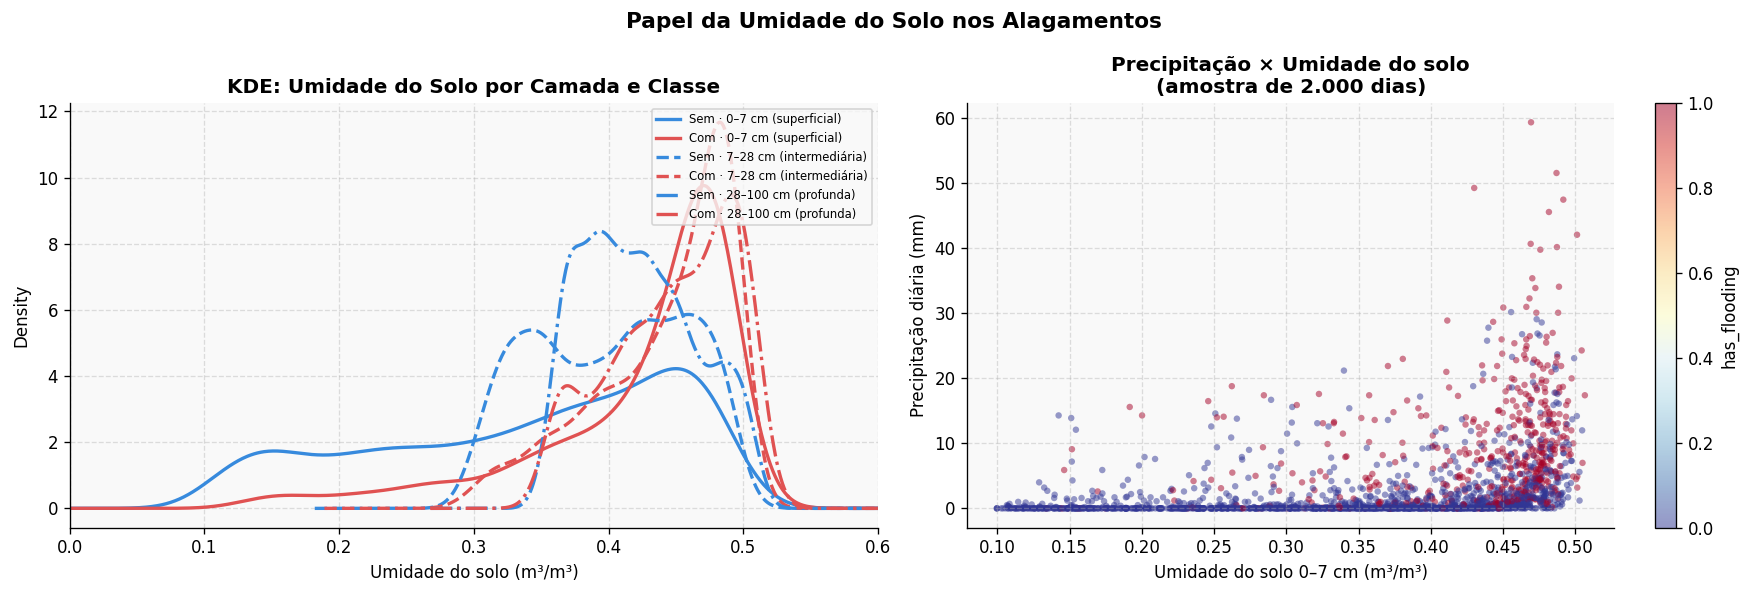

Taxa de alagamento por quartil de umidade do solo (0–7 cm):
             taxa  dias
soil_q                 
Q1 (seco)    7.4%  1044
Q2          16.2%  1041
Q3          26.4%  1042
Q4 (úmido)  48.9%  1042


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 7.1 Distribuição KDE por camada e classe
SOIL_LAYERS = [
    ("soil_moisture_0_to_7cm_mean",   "0–7 cm (superficial)"),
    ("soil_moisture_7_to_28cm_mean",  "7–28 cm (intermediária)"),
    ("soil_moisture_28_to_100cm_mean","28–100 cm (profunda)"),
]

ax = axes[0]
for i, (col, lbl) in enumerate(SOIL_LAYERS):
    linestyle = ["-", "--", "-."][i]
    df[df["has_flooding"]==0][col].plot.kde(ax=ax, color=BLUE, linestyle=linestyle,
                                             linewidth=2, label=f"Sem · {lbl}")
    df[df["has_flooding"]==1][col].plot.kde(ax=ax, color=RED, linestyle=linestyle,
                                             linewidth=2, label=f"Com · {lbl}")
ax.set_xlabel("Umidade do solo (m³/m³)")
ax.set_title("KDE: Umidade do Solo por Camada e Classe", fontweight="bold")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(0, 0.6)

# 7.2 Scatter: precipitação × umidade do solo, colorido pelo target
ax = axes[1]
sample = df.sample(min(2000, len(df)), random_state=42)
scatter = ax.scatter(
    sample["soil_moisture_0_to_7cm_mean"],
    sample["precipitation_sum"],
    c=sample["has_flooding"],
    cmap="RdYlBu_r",
    alpha=0.5, s=15, edgecolors="none"
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("has_flooding")
ax.set_xlabel("Umidade do solo 0–7 cm (m³/m³)")
ax.set_ylabel("Precipitação diária (mm)")
ax.set_title("Precipitação × Umidade do solo\n(amostra de 2.000 dias)", fontweight="bold")

plt.suptitle("Papel da Umidade do Solo nos Alagamentos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Análise quantitativa
print("Taxa de alagamento por quartil de umidade do solo (0–7 cm):")
df["soil_q"] = pd.qcut(df["soil_moisture_0_to_7cm_mean"], q=4,
                        labels=["Q1 (seco)","Q2","Q3","Q4 (úmido)"])
print(df.groupby("soil_q")["has_flooding"].agg(["mean","count"])
        .rename(columns={"mean":"taxa","count":"dias"})
        .assign(taxa=lambda x: (x["taxa"]*100).round(1).astype(str)+"%")
        .to_string())


## 8. Correlações com o Target e Entre Variáveis

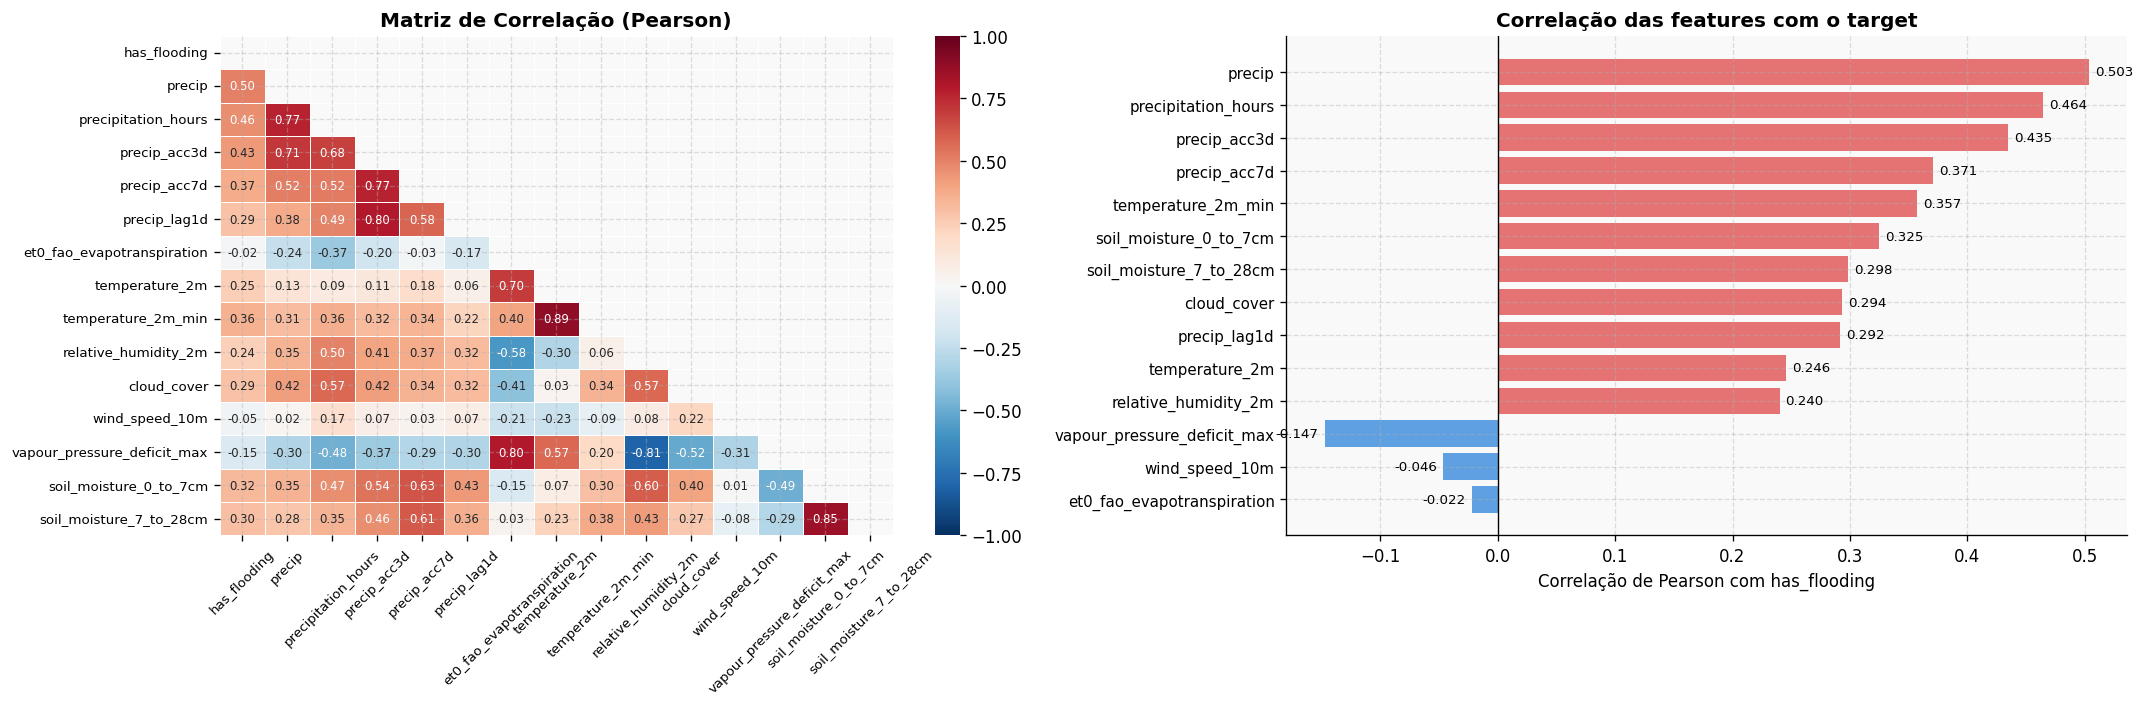

In [11]:
FEATURE_COLS = [
    "has_flooding",
    "precipitation_sum", "precipitation_hours",
    "precipitation_sum_acc3d", "precipitation_sum_acc7d",
    "precipitation_sum_lag1d",
    "et0_fao_evapotranspiration",
    "temperature_2m_mean", "temperature_2m_min",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
    "wind_speed_10m_mean",
    "vapour_pressure_deficit_max",
    "soil_moisture_0_to_7cm_mean",
    "soil_moisture_7_to_28cm_mean",
]

corr_matrix = df[FEATURE_COLS].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 8.1 Heatmap full
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], mask=mask, cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, fmt=".2f", annot=True,
            annot_kws={"size": 7}, linewidths=0.5,
            xticklabels=[c.replace("precipitation_sum","precip").replace("_mean","") for c in FEATURE_COLS],
            yticklabels=[c.replace("precipitation_sum","precip").replace("_mean","") for c in FEATURE_COLS])
axes[0].set_title("Matriz de Correlação (Pearson)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

# 8.2 Bar chart de correlações com has_flooding
corr_target = corr_matrix["has_flooding"].drop("has_flooding").sort_values(key=abs, ascending=True)
colors_bar  = [RED if v > 0 else BLUE for v in corr_target.values]
axes[1].barh(range(len(corr_target)), corr_target.values, color=colors_bar, alpha=0.8)
axes[1].set_yticks(range(len(corr_target)))
axes[1].set_yticklabels([c.replace("precipitation_sum","precip").replace("_mean","")
                          for c in corr_target.index], fontsize=9)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Correlação de Pearson com has_flooding")
axes[1].set_title("Correlação das features com o target", fontweight="bold")
for i, v in enumerate(corr_target.values):
    axes[1].text(v + (0.005 if v >= 0 else -0.005), i,
                 f"{v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.show()


## 9. Série Temporal — Precipitação e Alagamentos

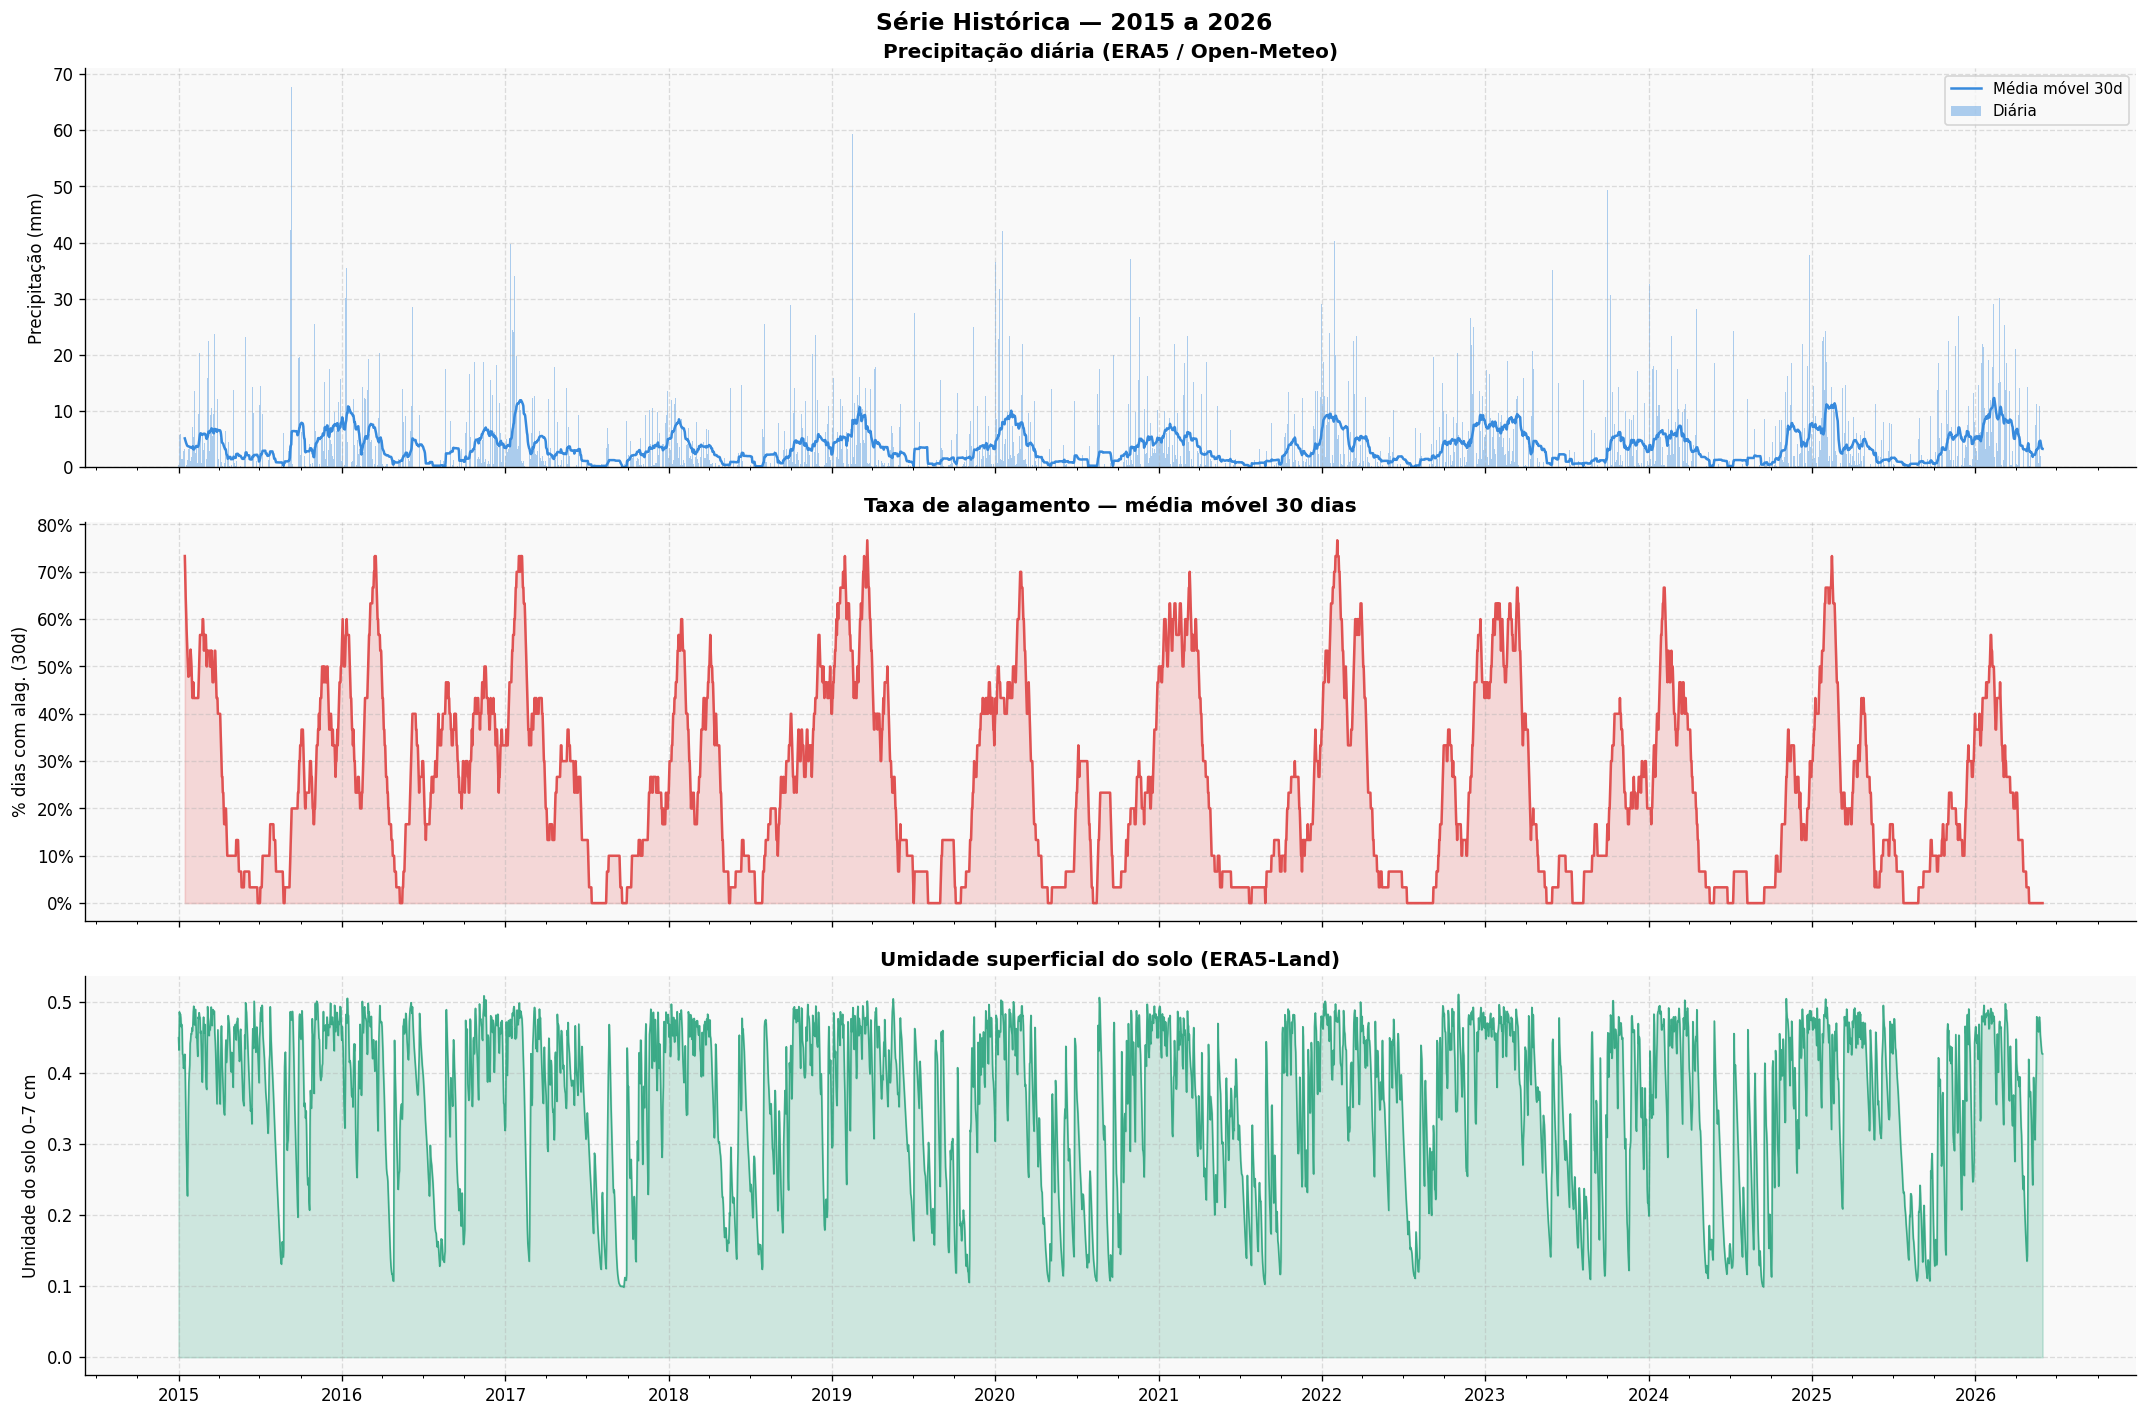

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Rolling 30 dias
df_sorted = df.sort_values("date").copy()
df_sorted["precip_30d"] = df_sorted["precipitation_sum"].rolling(30, min_periods=15).mean()
df_sorted["flood_30d"]  = df_sorted["has_flooding"].rolling(30, min_periods=15).mean() * 100

# 9.1 Precipitação diária + rolling
ax = axes[0]
ax.bar(df_sorted["date"], df_sorted["precipitation_sum"], color=BLUE, alpha=0.4, width=1.0, label="Diária")
ax.plot(df_sorted["date"], df_sorted["precip_30d"], color=BLUE, linewidth=1.5, label="Média móvel 30d")
ax.set_ylabel("Precipitação (mm)")
ax.set_title("Precipitação diária (ERA5 / Open-Meteo)", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)

# 9.2 Taxa de alagamento rolling 30d
ax = axes[1]
ax.plot(df_sorted["date"], df_sorted["flood_30d"], color=RED, linewidth=1.5)
ax.fill_between(df_sorted["date"], df_sorted["flood_30d"], alpha=0.2, color=RED)
ax.set_ylabel("% dias com alag. (30d)")
ax.set_title("Taxa de alagamento — média móvel 30 dias", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

# 9.3 Umidade do solo superficial
ax = axes[2]
ax.plot(df_sorted["date"], df_sorted["soil_moisture_0_to_7cm_mean"], color=GREEN, linewidth=1.0, alpha=0.8)
ax.fill_between(df_sorted["date"], df_sorted["soil_moisture_0_to_7cm_mean"],
                alpha=0.2, color=GREEN)
ax.set_ylabel("Umidade do solo 0–7 cm")
ax.set_title("Umidade superficial do solo (ERA5-Land)", fontweight="bold")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4,7,10]))

plt.suptitle("Série Histórica — 2015 a 2026", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Eventos Extremos e Limiares

In [13]:
# Dias com mais de N eventos
thresholds = [1, 3, 5, 10, 20]
print("Frequência de dias com alta quantidade de eventos:")
for t in thresholds:
    n = (df["n_events"] >= t).sum()
    print(f"  ≥ {t:>2} eventos/dia : {n:>4} dias ({n/len(df)*100:.1f}%)")

print()

# Relação precip threshold → P(alagamento)
print("P(alagamento | precipitação ≥ limiar):")
for lim in [0, 1, 5, 10, 20, 30, 50]:
    subset = df[df["precipitation_sum"] >= lim]
    if len(subset) > 0:
        rate = subset["has_flooding"].mean()
        print(f"  precip ≥ {lim:>2} mm : {len(subset):>5} dias → P(alag) = {rate:.1%}")


Frequência de dias com alta quantidade de eventos:
  ≥  1 eventos/dia : 1031 dias (24.7%)
  ≥  3 eventos/dia :  675 dias (16.2%)
  ≥  5 eventos/dia :  518 dias (12.4%)
  ≥ 10 eventos/dia :  327 dias (7.8%)
  ≥ 20 eventos/dia :  142 dias (3.4%)

P(alagamento | precipitação ≥ limiar):
  precip ≥  0 mm :  4169 dias → P(alag) = 24.7%
  precip ≥  1 mm :  1805 dias → P(alag) = 48.8%
  precip ≥  5 mm :   937 dias → P(alag) = 64.4%
  precip ≥ 10 mm :   512 dias → P(alag) = 74.6%
  precip ≥ 20 mm :   147 dias → P(alag) = 80.3%
  precip ≥ 30 mm :    39 dias → P(alag) = 84.6%
  precip ≥ 50 mm :     5 dias → P(alag) = 100.0%


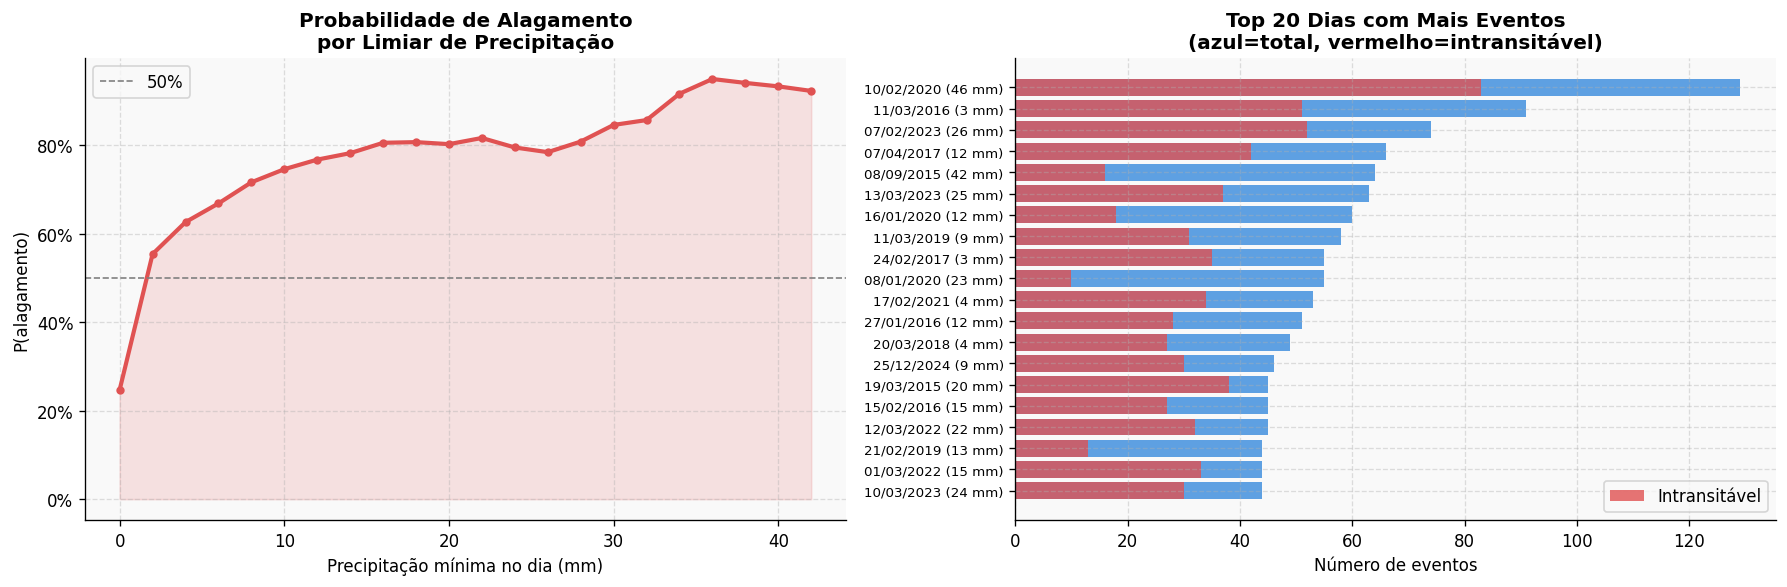

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 10.1 Curva P(alagamento) por limiar de precipitação
ax = axes[0]
limits = list(range(0, 55, 2))
probs  = [df[df["precipitation_sum"] >= l]["has_flooding"].mean() if (df["precipitation_sum"] >= l).sum() > 10 else np.nan
          for l in limits]
ax.plot(limits, probs, color=RED, linewidth=2.5, marker="o", markersize=4)
ax.fill_between(limits, probs, alpha=0.15, color=RED)
ax.set_xlabel("Precipitação mínima no dia (mm)")
ax.set_ylabel("P(alagamento)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Probabilidade de Alagamento\npor Limiar de Precipitação", fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="50%")
ax.legend()

# 10.2 Top 20 dias com mais eventos
ax = axes[1]
top_days = df.nlargest(20, "n_events")[["date","n_events","n_intransit","precipitation_sum"]].reset_index(drop=True)
colors   = [RED if r > 0 else BLUE for r in top_days["n_intransit"]]
bars     = ax.barh(range(len(top_days)),
                   top_days["n_events"], color=BLUE, alpha=0.8)
ax.barh(range(len(top_days)), top_days["n_intransit"], color=RED, alpha=0.8, label="Intransitável")
ax.set_yticks(range(len(top_days)))
ax.set_yticklabels([f"{r.date.strftime('%d/%m/%Y')} ({r.precipitation_sum:.0f} mm)"
                     for r in top_days.itertuples()], fontsize=8)
ax.set_xlabel("Número de eventos")
ax.set_title("Top 20 Dias com Mais Eventos\n(azul=total, vermelho=intransitável)", fontweight="bold")
ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()


## 11. Feature Importance Exploratória (Random Forest)

Dados para modelagem: 4,156 linhas × 21 features
Target: 24.6% positivos


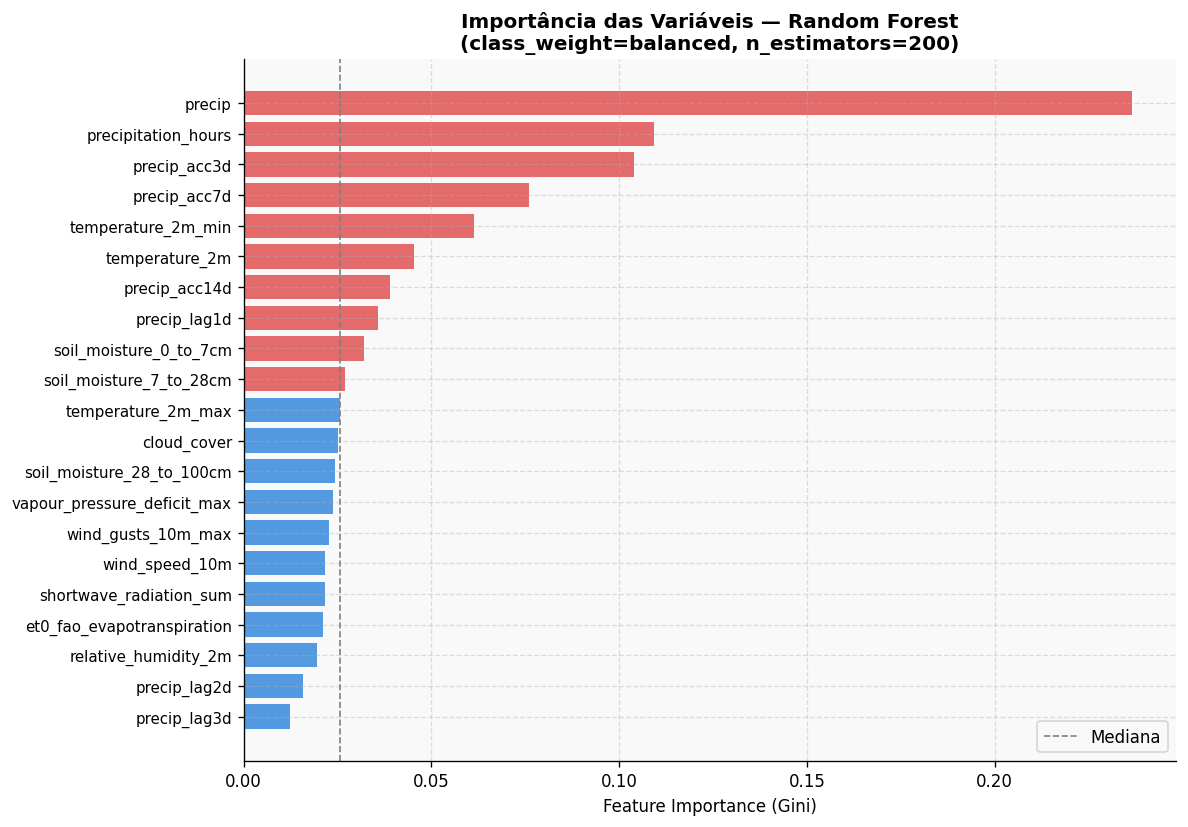


Top 10 features mais importantes:
precipitation_sum               0.236422
precipitation_hours             0.109263
precipitation_sum_acc3d         0.103916
precipitation_sum_acc7d         0.076054
temperature_2m_min              0.061220
temperature_2m_mean             0.045458
precipitation_sum_acc14d        0.038904
precipitation_sum_lag1d         0.035828
soil_moisture_0_to_7cm_mean     0.032133
soil_moisture_7_to_28cm_mean    0.026872


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit

FEATURES = [
    "precipitation_sum", "precipitation_hours",
    "precipitation_sum_lag1d", "precipitation_sum_lag2d", "precipitation_sum_lag3d",
    "precipitation_sum_acc3d", "precipitation_sum_acc7d", "precipitation_sum_acc14d",
    "et0_fao_evapotranspiration",
    "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min",
    "relative_humidity_2m_mean",
    "wind_speed_10m_mean", "wind_gusts_10m_max",
    "cloud_cover_mean", "shortwave_radiation_sum",
    "vapour_pressure_deficit_max",
    "soil_moisture_0_to_7cm_mean",
    "soil_moisture_7_to_28cm_mean",
    "soil_moisture_28_to_100cm_mean",
]

df_model = df[FEATURES + ["has_flooding"]].dropna()
X = df_model[FEATURES]
y = df_model["has_flooding"]

print(f"Dados para modelagem: {X.shape[0]:,} linhas × {X.shape[1]} features")
print(f"Target: {y.mean()*100:.1f}% positivos")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = [RED if v > imp.median() else BLUE for v in imp.values]
ax.barh(range(len(imp)), imp.values, color=colors_imp, alpha=0.85)
ax.set_yticks(range(len(imp)))
ax.set_yticklabels([c.replace("precipitation_sum","precip").replace("_mean","")
                    for c in imp.index], fontsize=9)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Importância das Variáveis — Random Forest\n(class_weight=balanced, n_estimators=200)",
             fontweight="bold")
ax.axvline(imp.median(), color="gray", linestyle="--", linewidth=1, label="Mediana")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 features mais importantes:")
print(imp.sort_values(ascending=False).head(10).to_string())


## 12. Modelos Base — Validação Temporal

⚠️ **Nota metodológica:** usamos `TimeSeriesSplit` para respeitar a ordem temporal dos dados.
Validação aleatória (k-fold padrão) causaria data leakage neste caso, pois eventos futuros
informariam o treinamento.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, f1_score, ConfusionMatrixDisplay
)

# ── Preparação ─────────────────────────────────────────────────────────────
df_model = df.sort_values("date").copy()
df_model = df_model[FEATURES + ["has_flooding"]].dropna()
X = df_model[FEATURES].values
y = df_model["has_flooding"].values

tscv = TimeSeriesSplit(n_splits=5)

# ── Modelos ────────────────────────────────────────────────────────────────
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
}

SCORING = ["f1", "roc_auc", "average_precision", "recall", "precision"]

results = {}
for name, model in models.items():
    print(f"Treinando {name}...")
    cv_res = cross_validate(model, X, y, cv=tscv, scoring=SCORING,
                            return_train_score=False, n_jobs=-1)
    results[name] = {metric: cv_res[f"test_{metric}"] for metric in SCORING}
    print(f"  F1={cv_res['test_f1'].mean():.3f}  AUC-ROC={cv_res['test_roc_auc'].mean():.3f}  AUC-PR={cv_res['test_average_precision'].mean():.3f}")

print("\n✓ Cross-validation concluída.")


Treinando Logistic Regression...
  F1=0.649  AUC-ROC=0.865  AUC-PR=0.676
Treinando Random Forest...
  F1=0.663  AUC-ROC=0.874  AUC-PR=0.677
Treinando Gradient Boosting...
  F1=0.624  AUC-ROC=0.864  AUC-PR=0.670

✓ Cross-validation concluída.


In [17]:
# Tabela de resultados
rows = []
for name, scores in results.items():
    rows.append({
        "Modelo"         : name,
        "F1"             : f"{scores['f1'].mean():.3f} ± {scores['f1'].std():.3f}",
        "AUC-ROC"        : f"{scores['roc_auc'].mean():.3f} ± {scores['roc_auc'].std():.3f}",
        "AUC-PR"         : f"{scores['average_precision'].mean():.3f} ± {scores['average_precision'].std():.3f}",
        "Recall"         : f"{scores['recall'].mean():.3f} ± {scores['recall'].std():.3f}",
        "Precision"      : f"{scores['precision'].mean():.3f} ± {scores['precision'].std():.3f}",
    })

results_df = pd.DataFrame(rows).set_index("Modelo")
print("=== Resultados — TimeSeriesSplit (5 folds) ===")
print(results_df.to_string())


=== Resultados — TimeSeriesSplit (5 folds) ===
                                F1        AUC-ROC         AUC-PR         Recall      Precision
Modelo                                                                                        
Logistic Regression  0.649 ± 0.045  0.865 ± 0.028  0.676 ± 0.042  0.783 ± 0.097  0.566 ± 0.075
Random Forest        0.663 ± 0.044  0.874 ± 0.031  0.677 ± 0.058  0.763 ± 0.103  0.602 ± 0.083
Gradient Boosting    0.624 ± 0.054  0.864 ± 0.041  0.670 ± 0.068  0.656 ± 0.111  0.619 ± 0.113


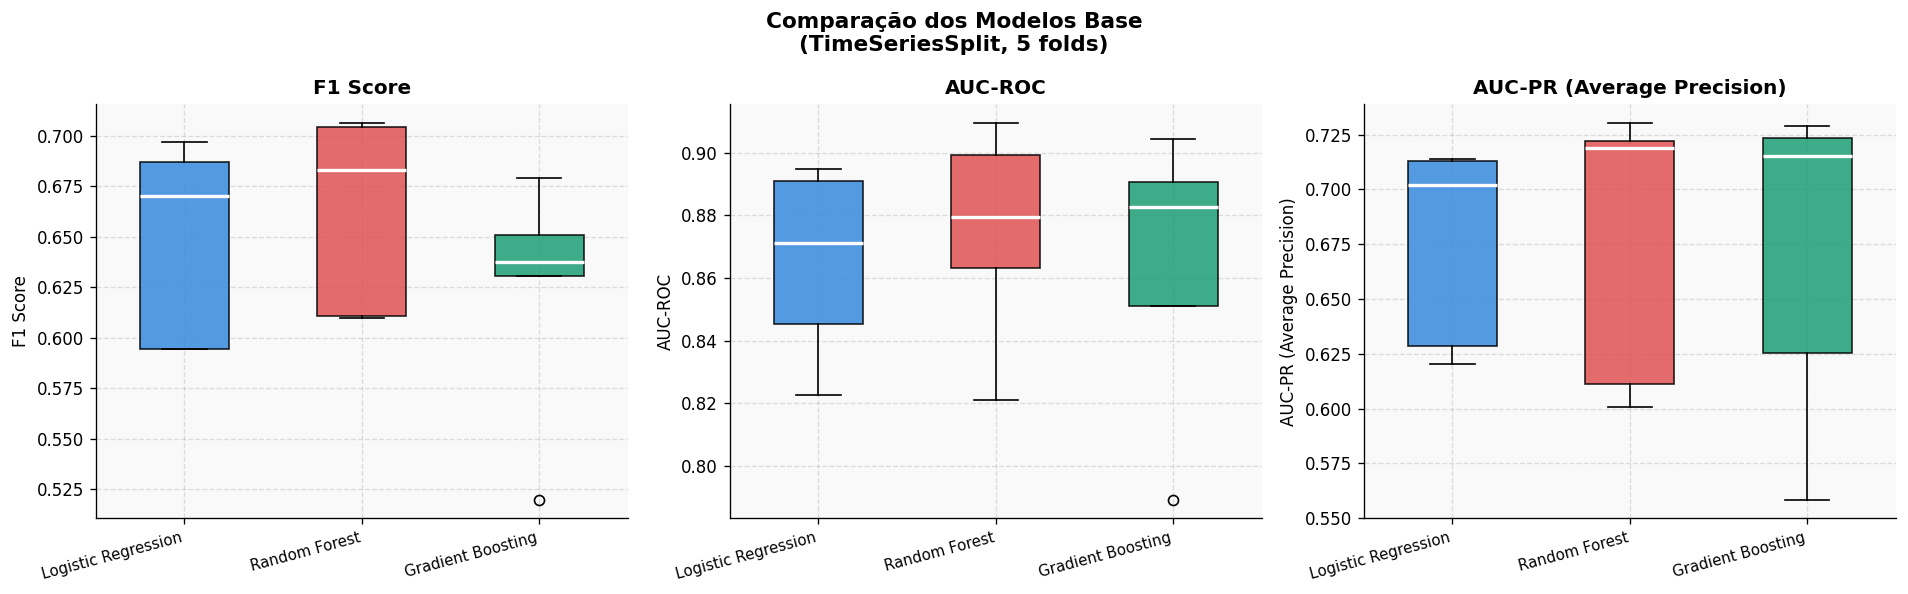

In [18]:
# Visualização comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_info = [
    ("f1",                  "F1 Score",                 axes[0]),
    ("roc_auc",             "AUC-ROC",                  axes[1]),
    ("average_precision",   "AUC-PR (Average Precision)",axes[2]),
]

colors_models = [BLUE, RED, GREEN]

for metric, label, ax in metric_info:
    for i, (name, scores) in enumerate(results.items()):
        vals = scores[metric]
        bp   = ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True,
                          medianprops=dict(color="white", linewidth=2))
        bp["boxes"][0].set_facecolor(colors_models[i])
        bp["boxes"][0].set_alpha(0.85)

    ax.set_xticks(range(len(results)))
    ax.set_xticklabels(list(results.keys()), rotation=15, ha="right", fontsize=9)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel(label)

plt.suptitle("Comparação dos Modelos Base\n(TimeSeriesSplit, 5 folds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Melhor modelo por F1: Random Forest


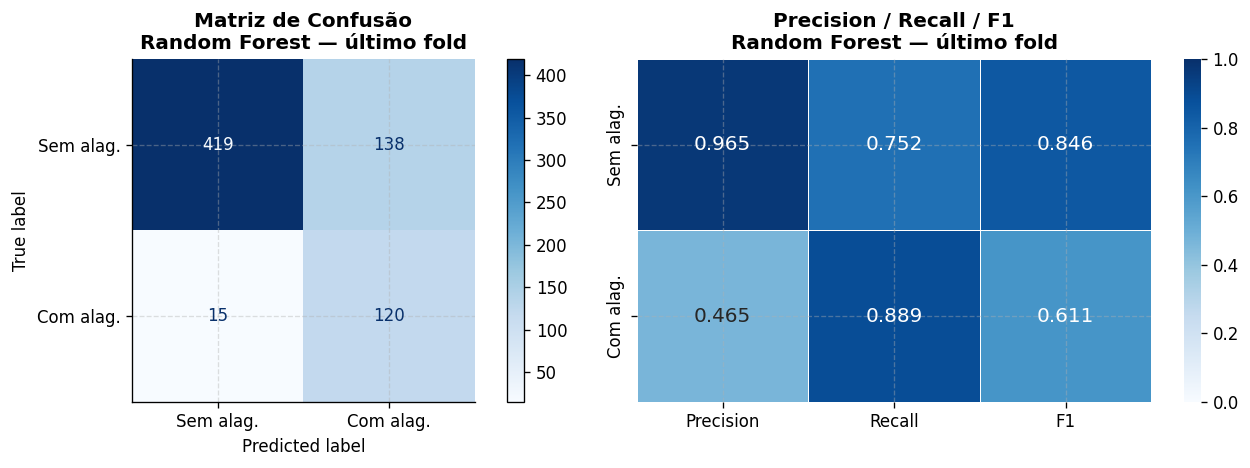


AUC-ROC (último fold): 0.8793
AUC-PR  (último fold): 0.6006

Classification report completo:
              precision    recall  f1-score   support

   Sem alag.       0.97      0.75      0.85       557
   Com alag.       0.47      0.89      0.61       135

    accuracy                           0.78       692
   macro avg       0.72      0.82      0.73       692
weighted avg       0.87      0.78      0.80       692



In [19]:
# Matriz de confusão — melhor modelo (Random Forest, último fold)
best_name = max(results, key=lambda n: results[n]["f1"].mean())
print(f"Melhor modelo por F1: {best_name}")

# Re-treinar no penúltimo split e avaliar no último
splits = list(tscv.split(X, y))
train_idx, test_idx = splits[-1]

best_model = models[best_name]
best_model.fit(X[train_idx], y[train_idx])
y_pred = best_model.predict(X[test_idx])
y_prob = best_model.predict_proba(X[test_idx])[:,1] if hasattr(best_model, "predict_proba") else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y[test_idx], y_pred),
                       display_labels=["Sem alag.", "Com alag."]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title(f"Matriz de Confusão\n{best_name} — último fold", fontweight="bold")

# Classification report como heatmap
report = classification_report(y[test_idx], y_pred,
                                target_names=["Sem alag.","Com alag."], output_dict=True)
report_df = pd.DataFrame(report).T.drop("support", axis=1).iloc[:2]
sns.heatmap(report_df, annot=True, fmt=".3f", cmap="Blues",
            ax=axes[1], vmin=0, vmax=1, linewidths=0.5, annot_kws={"size":12})
axes[1].set_title(f"Precision / Recall / F1\n{best_name} — último fold", fontweight="bold")
axes[1].set_xticklabels(["Precision","Recall","F1"], fontsize=10)

plt.tight_layout()
plt.show()

if y_prob is not None:
    print(f"\nAUC-ROC (último fold): {roc_auc_score(y[test_idx], y_prob):.4f}")
    print(f"AUC-PR  (último fold): {average_precision_score(y[test_idx], y_prob):.4f}")
print("\nClassification report completo:")
print(classification_report(y[test_idx], y_pred, target_names=["Sem alag.","Com alag."]))


## 13. Conclusões da EDA e Próximos Passos

## Conclusões da EDA

### Principais achados

1. **Desbalanceamento acentuado** (~75/25): qualquer modelo deve usar `class_weight='balanced'` ou técnicas de oversampling (SMOTE).

2. **Sazonalidade forte**: Janeiro concentra >55% dos dias com alagamento. Variáveis temporais (mês, `is_summer`) têm alto valor preditivo.

3. **Precipitação é o preditor mais forte** (corr ~0.50), mas não suficiente isoladamente — há dias com chuva intensa sem alagamento e vice-versa.

4. **Solo saturado amplifica o risco**: a umidade do solo 0–7 cm tem correlação de ~0.32 com o target e separa bem as classes. Quartil Q4 (solo úmido) tem taxa de alagamento ~3× maior que Q1.

5. **Acumulado de 3 dias** (acc3d) tem correlação quase igual à precipitação do dia — solo que já absorveu chuva nos dias anteriores contribui muito.

6. **Modelos base**: Random Forest e Gradient Boosting superam Regressão Logística em F1 e AUC-PR. Espaço para melhoria significativa com otimização de hiperparâmetros.

### Próximos passos

- [ ] Adicionar dados do CEMADEN (pluviômetros locais) quando disponíveis
- [ ] Otimizar hiperparâmetros com `optuna` ou `GridSearchCV` + `TimeSeriesSplit`
- [ ] Testar XGBoost, LightGBM e modelos de séries temporais (LSTM)
- [ ] Analisar erros: quais dias o modelo erra? Existe padrão geográfico?
- [ ] Avaliar por zona da cidade separadamente (Zona Leste pode ter padrão diferente)
- [ ] Threshold tuning: ajustar ponto de corte para maximizar Recall (falso negativo = não alertar = mais grave)
